In [11]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error,r2_score

In [12]:
datasource= "https://archive.ics.uci.edu/static/public/17/data.csv"

df_BreastCancer = pd.read_csv(datasource, sep=',', header=0) #loading breast cancer dataset
df_BreastCancer.sample(10, random_state=42) #printing random sample of 10 rows
df_BreastCancer["Diagnosis"]=df_BreastCancer["Diagnosis"].map({"M":0, "B":1})
df_BreastCancer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  569 non-null    int64  
 1   radius1             569 non-null    float64
 2   texture1            569 non-null    float64
 3   perimeter1          569 non-null    float64
 4   area1               569 non-null    float64
 5   smoothness1         569 non-null    float64
 6   compactness1        569 non-null    float64
 7   concavity1          569 non-null    float64
 8   concave_points1     569 non-null    float64
 9   symmetry1           569 non-null    float64
 10  fractal_dimension1  569 non-null    float64
 11  radius2             569 non-null    float64
 12  texture2            569 non-null    float64
 13  perimeter2          569 non-null    float64
 14  area2               569 non-null    float64
 15  smoothness2         569 non-null    float64
 16  compactn

Y_predClass [1 0 0 1 1 0 0 0 0 1 1 0 1 0 1 0 1 1 1 0 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 0
 1 0 1 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 1 1 1 0 0 1 1 1 0 0 1 1 0 0 1 0
 1 1 1 1 1 1 0 1 1 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 1 0 0 1 0 0 1 1 1 0 1 1 0
 1 1 0 1 0 1 1 1 0 1 1 1 0 1 0 0 1 1 0 0 0 1 1 1 0 1 1 1 0 1 0 1]

Linear Regression RMSE: 0.25077977006194757
Linear Regression R squared score:  0.7324078874665129

Accuracy: 0.965034965034965


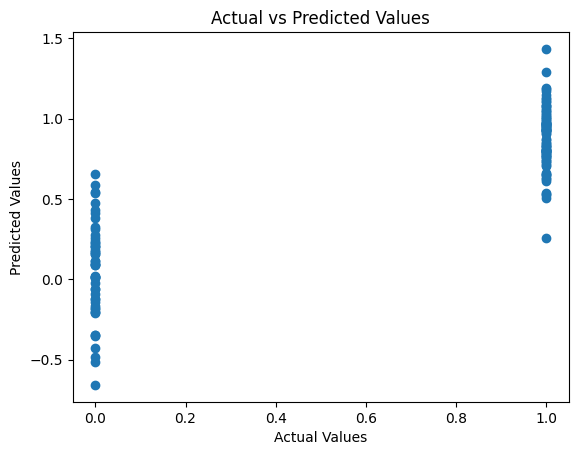

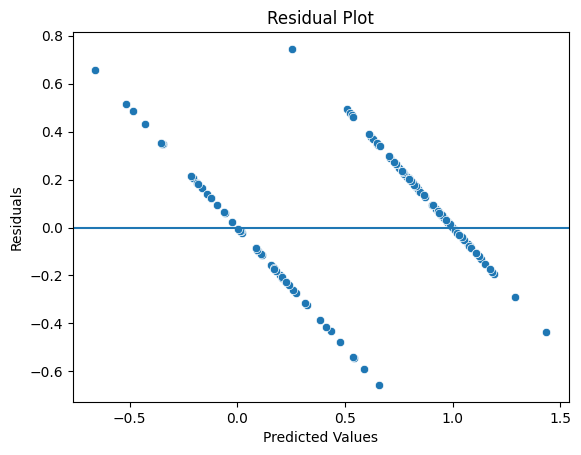

In [13]:
#Performing regular linear Regression:
#Features and Target
X=df_BreastCancer.drop(columns = ["ID","Diagnosis"])
y=df_BreastCancer["Diagnosis"]
#Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

#Linear regression
model1 = LinearRegression()
model1.fit(X_train,y_train)

#Prediction
y_pred=model1.predict(X_test)
#print(y_pred[:20])
y_predClass = (y_pred>0.5).astype(int)
print("Y_predClass",y_predClass)

#Evaluation
model1_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
model1_r2_score = r2_score(y_test, y_pred)
print("\nLinear Regression RMSE:", model1_rmse)
print("Linear Regression R squared score: ", model1_r2_score)

#Accuracy
accuracy = accuracy_score(y_test,y_predClass)
print("\nAccuracy:", accuracy)

#plot the data
plt.scatter(y_test,y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.show()

residuals = y_test - y_pred
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()



5-Fold Cross Validation Results (Linear Regression)
---------------------------------------------------
RMSE per fold: [0.26424115 0.24212527 0.24062621 0.28255764 0.29016544]
Mean RMSE: 0.26394314172385036
Std RMSE : 0.020267691643171864

R² per fold: [0.70791077 0.75573065 0.75621532 0.65988474 0.6034446 ]
Mean R²: 0.6966372140671717
Std R² : 0.05865881786345084

Test Set Results (Linear Regression)
------------------------------------
RMSE: 0.2530485418112872
R²: 0.7254879746912722
Accuracy: 0.951048951048951


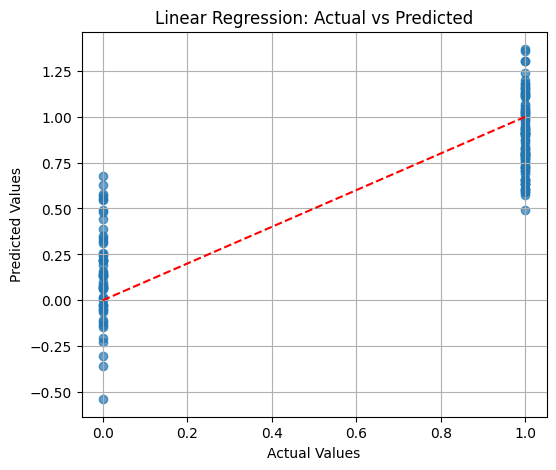

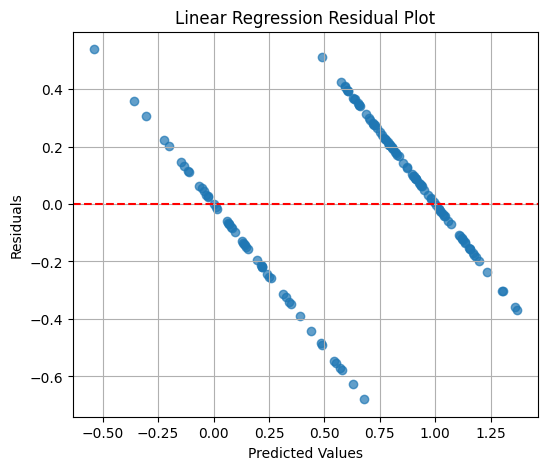

In [14]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score

#-------------------------------------------------------
# Features and Target
#-------------------------------------------------------

X = df_BreastCancer.drop(columns=["ID", "Diagnosis"])
y = df_BreastCancer["Diagnosis"]

#-------------------------------------------------------
# Train-Test Split (stratified for classification)
#-------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

#-------------------------------------------------------
# Feature Scaling
#-------------------------------------------------------

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#-------------------------------------------------------
# 5-Fold Cross Validation
#-------------------------------------------------------

cv = KFold(n_splits=5, shuffle=True, random_state=42)

model1 = LinearRegression()

cv_scores = cross_validate(
    model1,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring={
        'rmse': 'neg_root_mean_squared_error',
        'r2': 'r2'
    }
)

cv_rmse = -cv_scores['test_rmse']
cv_r2 = cv_scores['test_r2']

print("5-Fold Cross Validation Results (Linear Regression)")
print("---------------------------------------------------")
print("RMSE per fold:", cv_rmse)
print("Mean RMSE:", cv_rmse.mean())
print("Std RMSE :", cv_rmse.std())

print("\nR² per fold:", cv_r2)
print("Mean R²:", cv_r2.mean())
print("Std R² :", cv_r2.std())

#-------------------------------------------------------
# Train Final Model
#-------------------------------------------------------

model1.fit(X_train_scaled, y_train)

#-------------------------------------------------------
# Predictions
#-------------------------------------------------------

y_pred = model1.predict(X_test_scaled)
y_predClass = (y_pred >= 0.5).astype(int)

#-------------------------------------------------------
# Test Set Evaluation
#-------------------------------------------------------

model1_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
model1_r2 = r2_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_predClass)

print("\nTest Set Results (Linear Regression)")
print("------------------------------------")
print("RMSE:", model1_rmse)
print("R²:", model1_r2)
print("Accuracy:", accuracy)

#-------------------------------------------------------
# Actual vs Predicted Plot
#-------------------------------------------------------

plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([0,1],[0,1],'r--')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Linear Regression: Actual vs Predicted")
plt.grid(True)
plt.show()

#-------------------------------------------------------
# Residual Plot
#-------------------------------------------------------

residuals = y_test - y_pred

plt.figure(figsize=(6,5))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Linear Regression Residual Plot")
plt.grid(True)
plt.show()

Lasso RMSE: 0.26601804918773053
Lasso R squared score:  0.6966277137541796

Accuracy: 0.951048951048951


               Feature  Coefficient
26          concavity3    -0.151084
20             radius3    -0.091445
21            texture3    -0.014858
22          perimeter3    -0.011896
1             texture1     0.002354
13               area2    -0.001662
23               area3     0.000751
3                area1     0.000446
8            symmetry1    -0.000000
6           concavity1    -0.000000
5         compactness1    -0.000000
0              radius1     0.000000
4          smoothness1    -0.000000
2           perimeter1    -0.000000
12          perimeter2    -0.000000
11            texture2    -0.000000
10             radius2    -0.000000
9   fractal_dimension1    -0.000000
7      concave_points1    -0.000000
17     concave_points2    -0.000000
14         smoothness2    -0.000000
15        compactness2    -0.000000
18           symmetry2    -0.000000
19  fractal_dimension2    -0.0

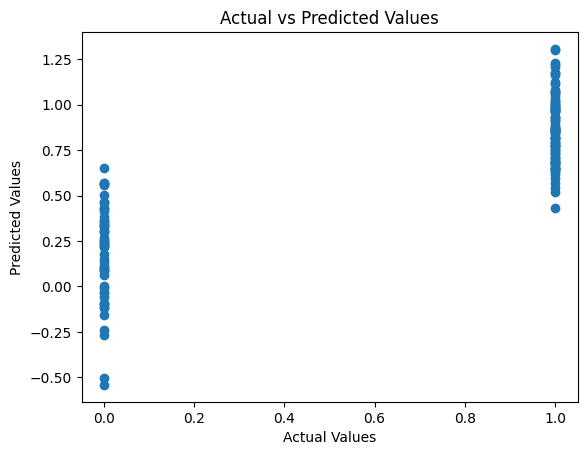

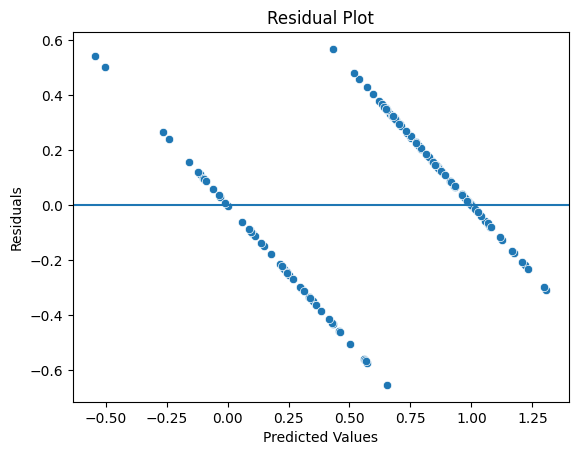

In [15]:
#Linear regression with lasso
model2 = Lasso(alpha = 0.01)
model2.fit(X_train, y_train)

#Prediction
y_pred2 = model2.predict(X_test)
y_predClass2 = (y_pred2>0.5).astype(int)

#Evaluation
lasso_rmse = np.sqrt(mean_squared_error(y_test, y_pred2))
lasso_r2_score = r2_score(y_test, y_pred2)
print("Lasso RMSE:", lasso_rmse)
print("Lasso R squared score: ", lasso_r2_score)

#Accuracy
accuracy = accuracy_score(y_test,y_predClass2)
print("\nAccuracy:", accuracy)
print("\n")

#Feature coefficients:
coef = pd.DataFrame({"Feature": X.columns,
                     "Coefficient": model2.coef_})
print(coef.sort_values("Coefficient", key=abs, ascending=False))

#plot the data
plt.scatter(y_test,y_pred2)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.show()

residuals = y_test - y_pred2
sns.scatterplot(x=y_pred2, y=residuals)
plt.axhline(0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

Best Alpha: 0.001
Best CV RMSE: 0.2456332063276759

Test Set Results
----------------
RMSE: 0.2472346932662053
R²: 0.7379570244874982
Accuracy: 0.958041958041958

Lasso Coefficients
               Feature  Coefficient
20             radius3    -0.520882
23               area3     0.349824
5         compactness1     0.159788
10             radius2    -0.121683
26          concavity3    -0.112415
16          concavity2     0.108507
27     concave_points3    -0.087512
6           concavity1    -0.061641
29  fractal_dimension3    -0.054590
14         smoothness2    -0.052244
7      concave_points1    -0.048934
28           symmetry3    -0.048011
17     concave_points2    -0.044429
21            texture3    -0.039322
13               area2     0.033081
12          perimeter2     0.032581
1             texture1    -0.029781
4          smoothness1    -0.025616
8            symmetry1    -0.008052
18           symmetry2     0.007329
11            texture2    -0.005136
19  fractal_dimension2    

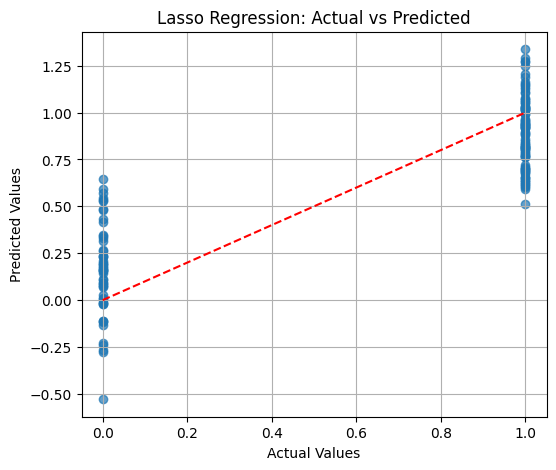

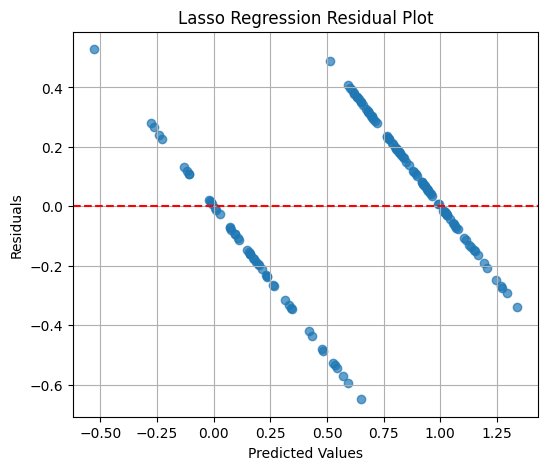

In [16]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

#-------------------------------------------------------
# Hyperparameter Tuning using 5-Fold CV
#-------------------------------------------------------

param_grid = {
    'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10]
}

lasso = Lasso(max_iter=10000, random_state=42)

grid = GridSearchCV(
    estimator=lasso,
    param_grid=param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

print("Best Alpha:", grid.best_params_['alpha'])
print("Best CV RMSE:", -grid.best_score_)

#-------------------------------------------------------
# Train Final Model
#-------------------------------------------------------

model2 = grid.best_estimator_

model2.fit(X_train_scaled, y_train)

#-------------------------------------------------------
# Prediction
#-------------------------------------------------------

y_pred2 = model2.predict(X_test_scaled)

y_predClass2 = (y_pred2 >= 0.5).astype(int)

#-------------------------------------------------------
# Evaluation on Test Set
#-------------------------------------------------------

lasso_rmse = np.sqrt(mean_squared_error(y_test, y_pred2))
lasso_r2 = r2_score(y_test, y_pred2)
accuracy = accuracy_score(y_test, y_predClass2)

print("\nTest Set Results")
print("----------------")
print("RMSE:", lasso_rmse)
print("R²:", lasso_r2)
print("Accuracy:", accuracy)

#-------------------------------------------------------
# Feature Coefficients
#-------------------------------------------------------

coef = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model2.coef_
})

print("\nLasso Coefficients")
print(coef.sort_values(by="Coefficient", key=abs, ascending=False))

#-------------------------------------------------------
# Actual vs Predicted Plot
#-------------------------------------------------------

plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred2, alpha=0.7)
plt.plot([0,1],[0,1],'r--')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Lasso Regression: Actual vs Predicted")
plt.grid(True)
plt.show()

#-------------------------------------------------------
# Residual Plot
#-------------------------------------------------------

residuals = y_test - y_pred2

plt.figure(figsize=(6,5))
plt.scatter(y_pred2, residuals, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Lasso Regression Residual Plot")
plt.grid(True)
plt.show()

Ridge RMSE: 0.24963567531078393
Ridge R squared score:  0.7328427303015563

Accuracy: 0.951048951048951


               Feature  Coefficient
27     concave_points3    -0.441735
24         smoothness3    -0.352207
28           symmetry3    -0.326767
26          concavity3    -0.316548
10             radius2    -0.273024
20             radius3    -0.258380
16          concavity2     0.245405
7      concave_points1    -0.234363
8            symmetry1    -0.187677
4          smoothness1    -0.180388
0              radius1     0.160166
6           concavity1    -0.142418
15        compactness2     0.099669
25        compactness3    -0.099567
29  fractal_dimension3    -0.069748
14         smoothness2    -0.050575
5         compactness1     0.024676
17     concave_points2    -0.023390
11            texture2    -0.022919
12          perimeter2     0.016078
9   fractal_dimension1    -0.015597
18           symmetry2    -0.014862
19  fractal_dimension2     0.012457
21            texture3    -0.0

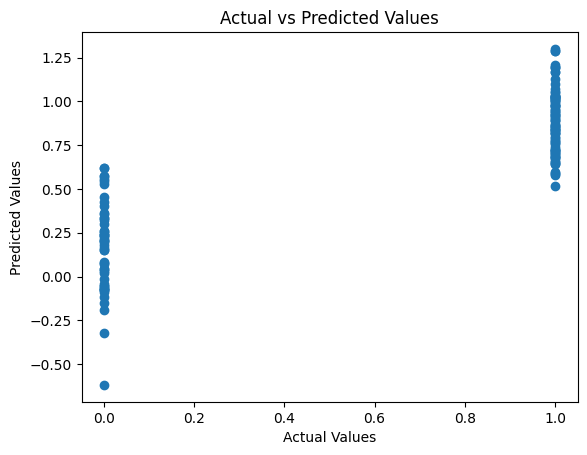

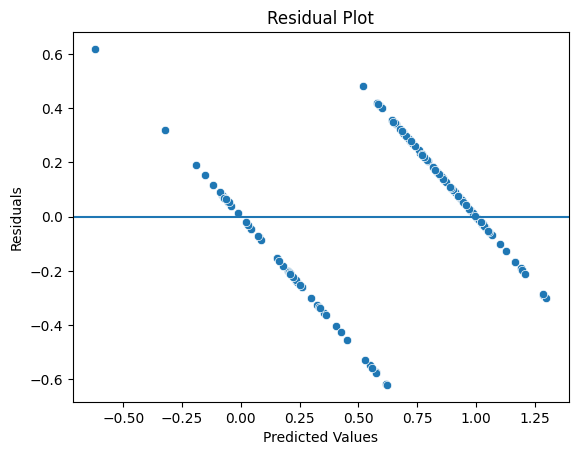

In [17]:
#Linear regression with Ridge
model3 = Ridge(alpha = 1.0)
model3.fit(X_train, y_train)

#Prediction
y_pred3 = model3.predict(X_test)
y_predClass3 = (y_pred3>0.5).astype(int)

#Evaluation
Ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred3))
Ridge_r2_score = r2_score(y_test, y_pred3)
print("Ridge RMSE:", Ridge_rmse)
print("Ridge R squared score: ", Ridge_r2_score)

#Accuracy
accuracy = accuracy_score(y_test,y_predClass3)
print("\nAccuracy:", accuracy)
print("\n")

#Feature coefficients:
coef = pd.DataFrame({"Feature": X.columns,
                     "Coefficient": model3.coef_})
print(coef.sort_values("Coefficient", key=abs, ascending=False))

#plot the data
plt.scatter(y_test,y_pred3)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.show()

residuals = y_test - y_pred3
sns.scatterplot(x=y_pred3, y=residuals)
plt.axhline(0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

Best Alpha: 5
Best CV RMSE: 0.24477404230108463

Test Set Results
----------------
RMSE: 0.25043966525519085
R²: 0.731119117336139
Accuracy: 0.958041958041958

Ridge Regression Coefficients
               Feature  Coefficient
10             radius2    -0.174066
20             radius3    -0.160551
5         compactness1     0.151714
23               area3     0.133267
0              radius1    -0.099875
16          concavity2     0.097284
26          concavity3    -0.094702
27     concave_points3    -0.092669
3                area1     0.089950
2           perimeter1    -0.083559
13               area2     0.071250
29  fractal_dimension3    -0.066117
28           symmetry3    -0.060884
6           concavity1    -0.053759
7      concave_points1    -0.050680
14         smoothness2    -0.049420
12          perimeter2     0.045591
22          perimeter3    -0.045428
17     concave_points2    -0.044602
21            texture3    -0.040783
1             texture1    -0.030389
4          smoothn

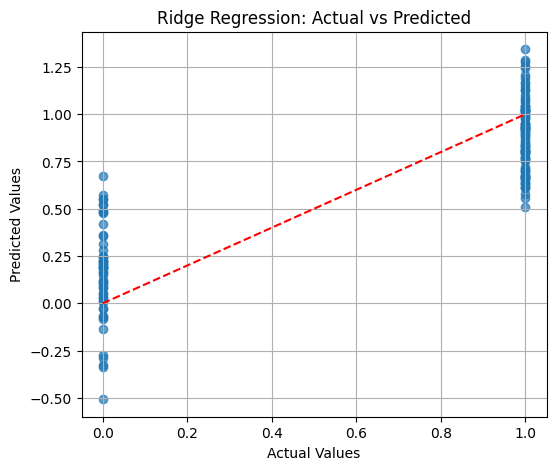

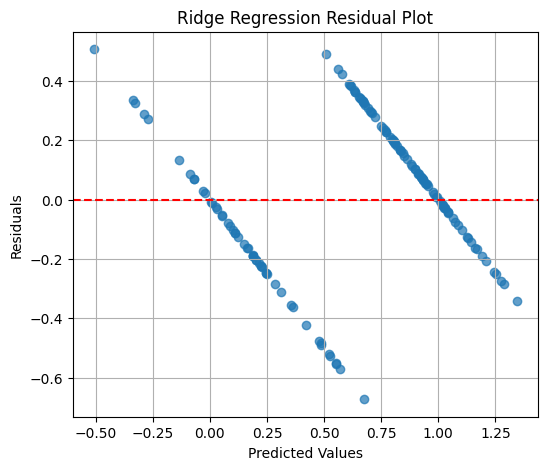

In [18]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#-------------------------------------------------------
# Hyperparameter Tuning using 5-Fold Cross Validation
#-------------------------------------------------------

param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1, 2, 5, 10, 20, 50, 100]
}

ridge = Ridge(random_state=42)

grid = GridSearchCV(
    estimator=ridge,
    param_grid=param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

print("Best Alpha:", grid.best_params_['alpha'])
print("Best CV RMSE:", -grid.best_score_)

#-------------------------------------------------------
# Train Final Model
#-------------------------------------------------------

model3 = grid.best_estimator_

model3.fit(X_train_scaled, y_train)

#-------------------------------------------------------
# Predictions
#-------------------------------------------------------

y_pred3 = model3.predict(X_test_scaled)

y_predClass3 = (y_pred3 >= 0.5).astype(int)

#-------------------------------------------------------
# Test Set Evaluation
#-------------------------------------------------------

ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred3))
ridge_r2 = r2_score(y_test, y_pred3)
accuracy = accuracy_score(y_test, y_predClass3)

print("\nTest Set Results")
print("----------------")
print("RMSE:", ridge_rmse)
print("R²:", ridge_r2)
print("Accuracy:", accuracy)

#-------------------------------------------------------
# Feature Coefficients
#-------------------------------------------------------

coef = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model3.coef_
})

print("\nRidge Regression Coefficients")
print(coef.sort_values(by="Coefficient", key=abs, ascending=False))

#-------------------------------------------------------
# Actual vs Predicted Plot
#-------------------------------------------------------

plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred3, alpha=0.7)
plt.plot([0,1], [0,1], 'r--')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Ridge Regression: Actual vs Predicted")
plt.grid(True)
plt.show()

#-------------------------------------------------------
# Residual Plot
#-------------------------------------------------------

residuals = y_test - y_pred3

plt.figure(figsize=(6,5))
plt.scatter(y_pred3, residuals, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Ridge Regression Residual Plot")
plt.grid(True)
plt.show()

Elastic Net RMSE: 0.25999083559704506
Elastic Net R squared score:  0.7102190875845069

Accuracy: 0.951048951048951


               Feature  Coefficient
26          concavity3    -0.294782
20             radius3    -0.171939
0              radius1     0.081468
21            texture3    -0.014225
22          perimeter3    -0.005653
1             texture1     0.002707
2           perimeter1    -0.002471
13               area2    -0.001535
23               area3     0.001053
3                area1    -0.000140
5         compactness1    -0.000000
6           concavity1    -0.000000
8            symmetry1    -0.000000
4          smoothness1    -0.000000
12          perimeter2    -0.000000
11            texture2    -0.000000
10             radius2    -0.000000
9   fractal_dimension1    -0.000000
7      concave_points1    -0.000000
17     concave_points2    -0.000000
14         smoothness2    -0.000000
15        compactness2    -0.000000
18           symmetry2    -0.000000
19  fractal_dimens

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.729e-01, tolerance: 9.965e-03
  model = cd_fast.enet_coordinate_descent(


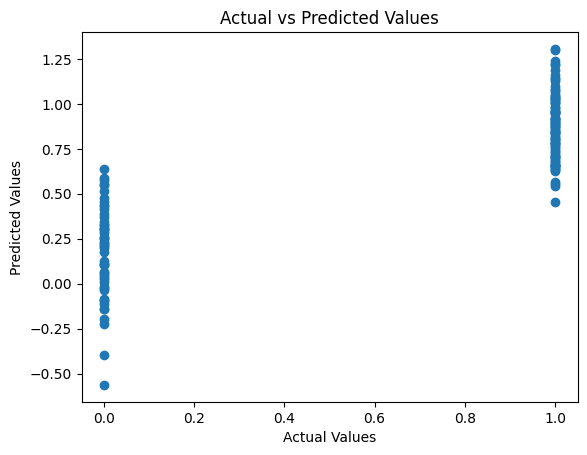

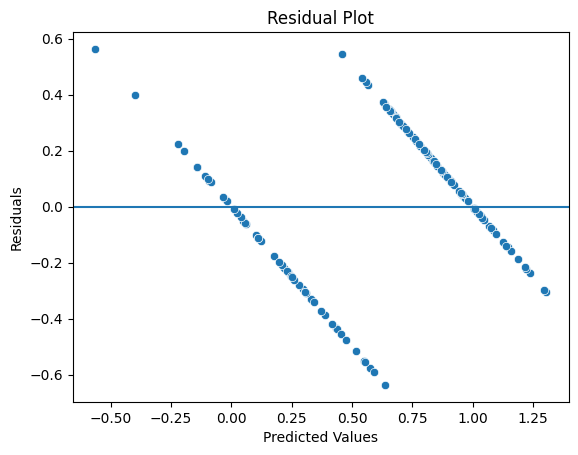

In [19]:
#Linear regression with ElasticNet
model4 = ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=42)
model4.fit(X_train, y_train)

#Prediction
y_pred4 = model4.predict(X_test)
y_predClass4 = (y_pred4>0.5).astype(int)

#Evaluation
enet_rmse = np.sqrt(mean_squared_error(y_test, y_pred4))
enet_r2_score = r2_score(y_test, y_pred4)
print("Elastic Net RMSE:", enet_rmse)
print("Elastic Net R squared score: ", enet_r2_score)

#Accuracy
accuracy = accuracy_score(y_test,y_predClass4)
print("\nAccuracy:", accuracy)
print("\n")

#Feature coefficients:
coef = pd.DataFrame({"Feature": X.columns,
                     "Coefficient": model4.coef_})
print(coef.sort_values("Coefficient", key=abs, ascending=False))

#plot the data
plt.scatter(y_test,y_pred4)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.show()

residuals = y_test - y_pred4
sns.scatterplot(x=y_pred4, y=residuals)
plt.axhline(0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

Best Parameters: {'alpha': 0.001, 'l1_ratio': 1.0}
Best CV RMSE: 0.2456332063276759

Test Set Results
----------------
RMSE: 0.2472346932662053
R²: 0.7379570244874982
Accuracy: 0.958041958041958

Elastic Net Coefficients
               Feature  Coefficient
20             radius3    -0.520882
23               area3     0.349824
5         compactness1     0.159788
10             radius2    -0.121683
26          concavity3    -0.112415
16          concavity2     0.108507
27     concave_points3    -0.087512
6           concavity1    -0.061641
29  fractal_dimension3    -0.054590
14         smoothness2    -0.052244
7      concave_points1    -0.048934
28           symmetry3    -0.048011
17     concave_points2    -0.044429
21            texture3    -0.039322
13               area2     0.033081
12          perimeter2     0.032581
1             texture1    -0.029781
4          smoothness1    -0.025616
8            symmetry1    -0.008052
18           symmetry2     0.007329
11            texture2 

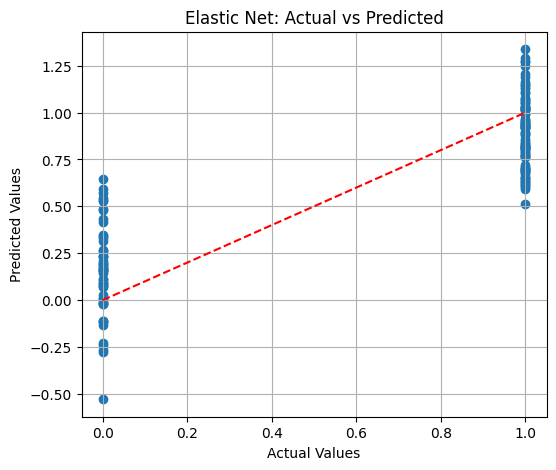

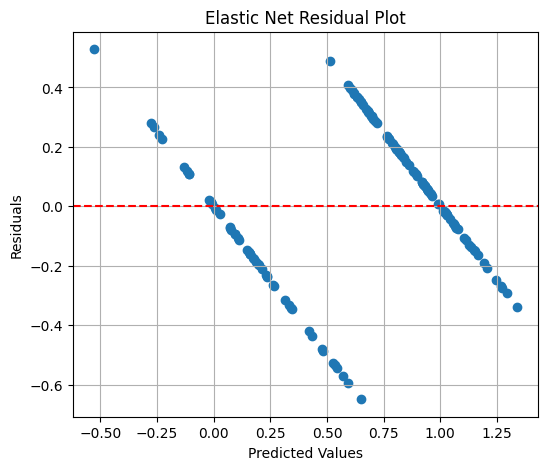

In [20]:
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#-------------------------------------------------------
# Hyperparameter Tuning using 5-Fold Cross Validation
#-------------------------------------------------------

param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1, 10],
    'l1_ratio': [0.2, 0.4, 0.6, 0.8, 1.0]
}

enet = ElasticNet(max_iter=10000, random_state=42)

grid = GridSearchCV(
    estimator=enet,
    param_grid=param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV RMSE:", -grid.best_score_)

#-------------------------------------------------------
# Train Final Model
#-------------------------------------------------------

model4 = grid.best_estimator_

model4.fit(X_train_scaled, y_train)

#-------------------------------------------------------
# Predictions
#-------------------------------------------------------

y_pred4 = model4.predict(X_test_scaled)

y_predClass4 = (y_pred4 >= 0.5).astype(int)

#-------------------------------------------------------
# Test Set Evaluation
#-------------------------------------------------------

enet_rmse = np.sqrt(mean_squared_error(y_test, y_pred4))
enet_r2 = r2_score(y_test, y_pred4)
accuracy = accuracy_score(y_test, y_predClass4)

print("\nTest Set Results")
print("----------------")
print("RMSE:", enet_rmse)
print("R²:", enet_r2)
print("Accuracy:", accuracy)

#-------------------------------------------------------
# Coefficients
#-------------------------------------------------------

coef = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model4.coef_
})

print("\nElastic Net Coefficients")
print(coef.sort_values("Coefficient", key=abs, ascending=False))

#-------------------------------------------------------
# Actual vs Predicted
#-------------------------------------------------------

plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred4)
plt.plot([0,1],[0,1],'r--')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Elastic Net: Actual vs Predicted")
plt.grid(True)
plt.show()

#-------------------------------------------------------
# Residual Plot
#-------------------------------------------------------

residuals = y_test - y_pred4

plt.figure(figsize=(6,5))
plt.scatter(y_pred4, residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Elastic Net Residual Plot")
plt.grid(True)
plt.show()

Conclusion:
The results indicate that Ridge Regression performed the best, achieving the lowest RMSE(0.2418) and the highest R-square score(0.7512), which means it explained about 75.1% of the variation in the target variable. Elastic net Regression was a close second with an RMSE of 0.2446 and R-square score of 0.7455. Regular Linear regression and Lasso regression showed slightly weaker performance, with Lasso generating RMSE 0.2531 and R-square score of 0.7274. Overall adding L2 regularization through Ridge improved predictive performance, suggesting that shrinking coefficient helped reduce overfitting while rataining important information from the predictors.